# Amazon Sales Dataset - EDA (Exploratory Data Analysis)

## 📊 분석 개요

본 노트북은 **Amazon Sales Dataset**의 탐색적 데이터 분석(EDA)을 수행한다.  
데이터 구조 파악, 기초 통계, 결측치 확인, 분포 분석 등을 통해 데이터의 특성을 이해하고,  
후속 코호트 분석 및 리텐션 분석을 위한 기반을 마련한다.

---

## 📋 데이터셋 정보

### 컬럼 설명

| 컬럼명 | 타입 | 설명 |
|--------|------|------|
| **OrderDate** | datetime | 주문 발생 날짜 |
| **CustomerID** | object | 고객 고유 ID |
| **ProductID** | object | 상품 고유 ID |
| **Category** | object | 상품 카테고리 (예: Books, Electronics 등) |
| **Brand** | object | 상품 브랜드 (예: Samsung, Apple 등) |
| **Discount** | float | 할인율 (0.0 ~ 1.0) |
| **TotalAmount** | float | 최종 결제 금액 (USD) |
| **PaymentMethod** | object | 결제 방식 (예: Credit Card, Amazon Pay 등) |

In [25]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import plotly.express as px
from plotly.subplots import make_subplots

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

In [26]:
from dotenv import load_dotenv
import os

load_dotenv()  # .env 파일 로드

# MySQL 연결
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)


# 데이터 로드
df = pd.read_sql("SELECT * FROM orders_info", engine)

In [27]:
# 상위 5개 행
df.head()

,OrderID,OrderDate,CustomerID,ProductID,Category,Brand,Discount,TotalAmount,PaymentMethod
0,ORD0000001,2023-01-31,CUST001504,P00014,Books,BrightLux,0.00,319.86,Debit Card
1,ORD0000002,2023-12-30,CUST000178,P00040,Home & Kitchen,UrbanStyle,0.05,259.64,Amazon Pay
2,ORD0000003,2022-05-10,CUST047516,P00044,Clothing,UrbanStyle,0.10,108.06,Debit Card
3,ORD0000004,2023-07-18,CUST030059,P00041,Home & Kitchen,Zenith,0.15,159.66,Cash on Delivery
4,ORD0000005,2023-02-04,CUST048677,P00029,Clothing,KiddoFun,0.25,821.36,Credit Card


In [28]:
# 데이터 크기
df.shape

(100000, 9)

In [29]:
# 데이터 타입 및 결측치
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   ProductID      100000 non-null  object        
 4   Category       100000 non-null  object        
 5   Brand          100000 non-null  object        
 6   Discount       100000 non-null  float64       
 7   TotalAmount    100000 non-null  float64       
 8   PaymentMethod  100000 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 6.9+ MB


In [30]:
# 결측치 확인
missing = df.isnull().sum()
missing

OrderID          0
OrderDate        0
CustomerID       0
ProductID        0
Category         0
Brand            0
Discount         0
TotalAmount      0
PaymentMethod    0
dtype: int64

In [31]:
# 중복 데이터 확인
duplicates = df.duplicated().sum()
duplicates

0

In [32]:
# 수치형 컬럼 기술 통계
df.describe()

,OrderDate,Discount,TotalAmount
count,100000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.440000,0.074226,918.256479
min,2020-01-01 00:00:00,0.000000,4.270000
25%,2021-04-01 00:00:00,0.000000,340.890000
50%,2022-07-01 00:00:00,0.050000,714.315000
75%,2023-09-29 00:00:00,0.100000,1349.765000
max,2024-12-29 00:00:00,0.300000,3534.980000
std,NaN,0.082583,724.508332


In [33]:
# 범주형 컬럼 
categorical_cols = ['CustomerID', 'ProductID', 'Category', 'Brand', 'PaymentMethod']

for col in categorical_cols:
    print(f"\n[{col}]")
    print(f"  고유값 개수: {df[col].nunique():,}")
    print(f"  최빈값: {df[col].mode()[0]}")
    print(f"  최빈값 빈도: {df[col].value_counts().iloc[0]:,}")


[CustomerID]
  고유값 개수: 43,233
  최빈값: CUST023748
  최빈값 빈도: 10

[ProductID]
  고유값 개수: 50
  최빈값: P00019
  최빈값 빈도: 2,098

[Category]
  고유값 개수: 6
  최빈값: Electronics
  최빈값 빈도: 16,853

[Brand]
  고유값 개수: 10
  최빈값: ReadMore
  최빈값 빈도: 10,204

[PaymentMethod]
  고유값 개수: 6
  최빈값: Credit Card
  최빈값 빈도: 35,038


In [34]:
# 주문 날짜 범위
print(f"최초 주문일: {df['OrderDate'].min()}")
print(f"마지막 주문일: {df['OrderDate'].max()}")
print(f"기간: {(df['OrderDate'].max() - df['OrderDate'].min()).days}일")

최초 주문일: 2020-01-01 00:00:00
마지막 주문일: 2024-12-29 00:00:00
기간: 1824일


In [35]:
# 월별 주문 건수
df['YearMonth'] = df['OrderDate'].dt.to_period('M')
monthly_orders = df.groupby('YearMonth').size().reset_index(name='주문건수')
monthly_orders['YearMonth'] = monthly_orders['YearMonth'].astype(str)

monthly_orders.head()

,YearMonth,주문건수
0,2020-01,1730
1,2020-02,1490
2,2020-03,1685
3,2020-04,1692
4,2020-05,1672


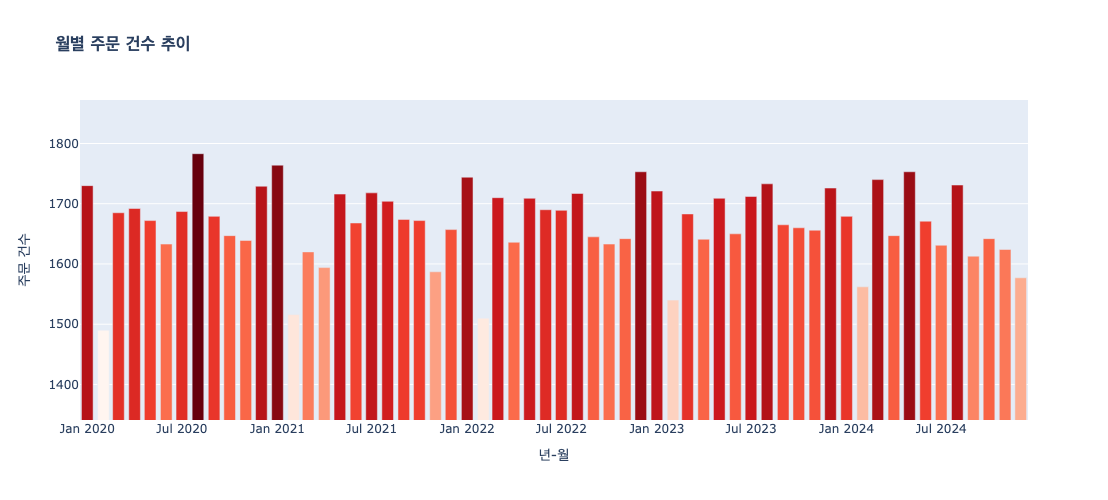

In [54]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Bar(
    x=monthly_orders['YearMonth'],
    y=monthly_orders['주문건수'],
    textposition='outside',
    marker=dict(
        color=monthly_orders['주문건수'],
        colorscale='Reds',
        showscale=False
    )
))

# Y축 시작점을 최소값 근처로 설정
y_min = monthly_orders['주문건수'].min() * 0.9
y_max = monthly_orders['주문건수'].max() * 1.05

fig.update_layout(
    title='<b>월별 주문 건수 추이</b>',
    xaxis_title='년-월',
    yaxis_title='주문 건수',
    yaxis_range=[y_min, y_max],  # 범위 조정
    height=500,
    showlegend=False
)

fig.show()

In [37]:
# 연도별 주문 건수 및 고객 수
yearly_stats = df.groupby(df['OrderDate'].dt.year).agg(
    주문건수=('OrderID', 'count'),
    고객수=('CustomerID', 'nunique')
).reset_index()
yearly_stats.columns = ['연도', '주문건수', '고객수']
yearly_stats['연도'] = yearly_stats['연도'].astype(str)

yearly_stats

,연도,주문건수,고객수
0,2020,20066,16544
1,2021,19890,16446
2,2022,20078,16517
3,2023,20096,16558
4,2024,19870,16360


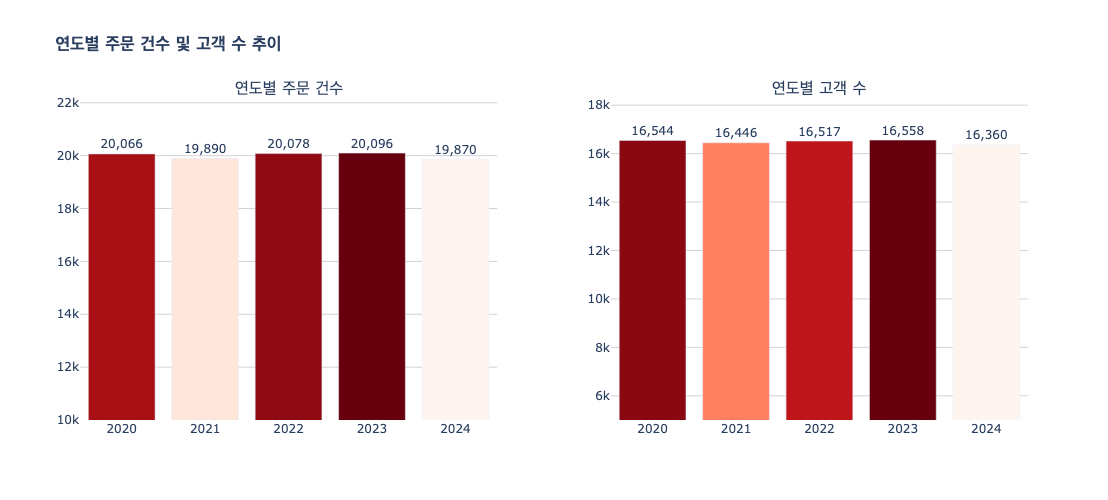

In [53]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('연도별 주문 건수', '연도별 고객 수'),
    horizontal_spacing=0.12
)

fig.add_trace(
    go.Bar(
        x=yearly_stats['연도'],
        y=yearly_stats['주문건수'],
        text=yearly_stats['주문건수'].apply(lambda x: f'{x:,}'),
        textposition='outside',
        marker=dict(
            color=yearly_stats['주문건수'],
            colorscale='Reds',
            showscale=False
        )
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=yearly_stats['연도'],
        y=yearly_stats['고객수'],
        text=yearly_stats['고객수'].apply(lambda x: f'{x:,}'),
        textposition='outside',
        marker=dict(
            color=yearly_stats['고객수'],
            colorscale='Reds',
            showscale=False
        )
    ),
    row=1, col=2
)

y1_max = yearly_stats['주문건수'].max()
y2_max = yearly_stats['고객수'].max()

fig.update_layout(
    title='<b>연도별 주문 건수 및 고객 수 추이</b>',
    plot_bgcolor='white',
    height=500,
    showlegend=False,
    yaxis=dict(showgrid=True, gridcolor='lightgray', range=[10000, y1_max * 1.1]),
    yaxis2=dict(showgrid=True, gridcolor='lightgray', range=[5000, y2_max * 1.1])
)

fig.show()

In [13]:
# 카테고리별 주문 건수
category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['카테고리', '주문건수']
category_counts['비율(%)'] = (category_counts['주문건수'] / len(df) * 100).round(2)

category_counts

,카테고리,주문건수,비율(%)
0,Electronics,16853,16.85
1,Sports & Outdoors,16804,16.80
2,Books,16752,16.75
3,Home & Kitchen,16610,16.61
4,Toys & Games,16542,16.54
5,Clothing,16439,16.44


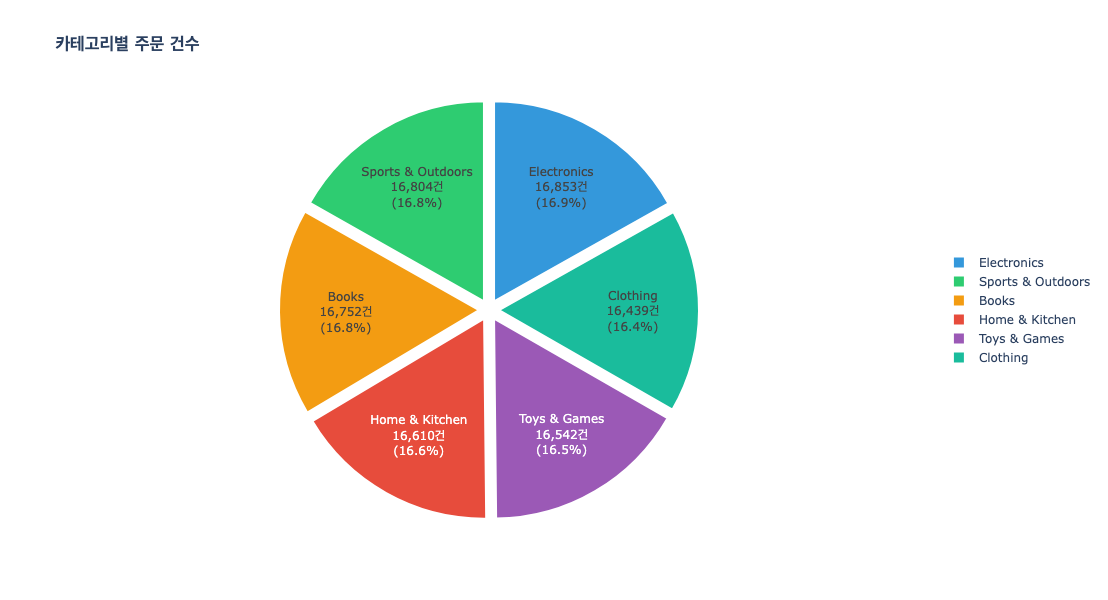

In [14]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Pie(
    labels=category_counts['카테고리'],
    values=category_counts['주문건수'],
    texttemplate='%{label}<br>%{value:,}건<br>(%{percent})',
    textposition='auto',
    marker=dict(
        colors=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c'],
        line=dict(color='white', width=2)
    ),
    pull=[0.05] * len(category_counts), 
    hovertemplate='<b>%{label}</b><br>주문건수: %{value:,}건<br>비율: %{percent}<extra></extra>'
))

fig.update_layout(
    title='<b>카테고리별 주문 건수</b>',
    height=600,
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.05
    )
)

fig.show()

## 6. 결제 방식 분석

In [15]:
# 결제 방식별 주문 건수
payment_counts = df['PaymentMethod'].value_counts().reset_index()
payment_counts.columns = ['결제방식', '주문건수']
payment_counts['비율(%)'] = (payment_counts['주문건수'] / len(df) * 100).round(2)

payment_counts

,결제방식,주문건수,비율(%)
0,Credit Card,35038,35.04
1,Debit Card,20024,20.02
2,UPI,15066,15.07
3,Amazon Pay,15017,15.02
4,Net Banking,9927,9.93
5,Cash on Delivery,4928,4.93


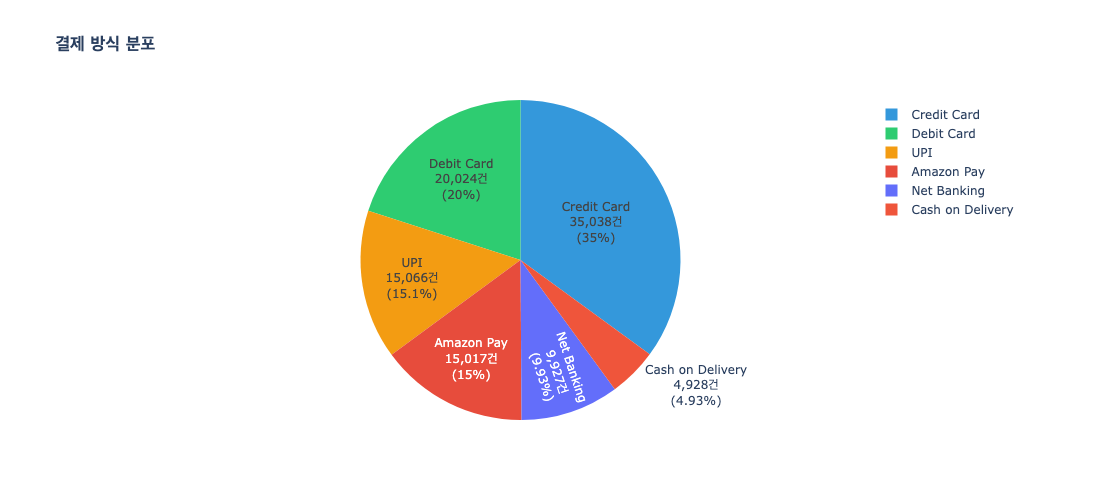

In [16]:
# 결제 방식 파이 차트
fig = go.Figure()

fig.add_trace(go.Pie(
    labels=payment_counts['결제방식'],
    values=payment_counts['주문건수'],
    texttemplate='%{label}<br>%{value:,}건<br>(%{percent})',
    textposition='auto',
    marker=dict(colors=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
))

fig.update_layout(
    title='<b>결제 방식 분포</b>',
    height=500
)

fig.show()

In [17]:
# 할인 기본 통계
print(f"할인 있는 주문: {(df['Discount'] > 0).sum():,}건 ({(df['Discount'] > 0).mean() * 100:.2f}%)")
print(f"할인 없는 주문: {(df['Discount'] == 0).sum():,}건 ({(df['Discount'] == 0).mean() * 100:.2f}%)")
print(f"\n평균 할인율: {df[df['Discount'] > 0]['Discount'].mean() * 100:.2f}%")
print(f"최대 할인율: {df['Discount'].max() * 100:.2f}%")

할인 있는 주문: 59,754건 (59.75%)
할인 없는 주문: 40,246건 (40.25%)

평균 할인율: 12.42%
최대 할인율: 30.00%


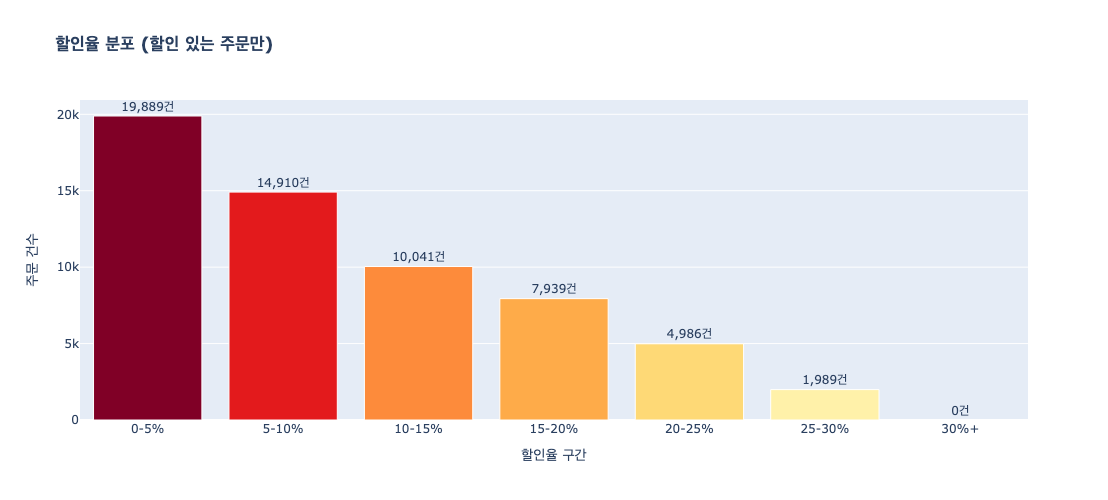

In [18]:
import plotly.graph_objects as go
import numpy as np

# 할인율 데이터
discount_data = df[df['Discount'] > 0]['Discount'] * 100

# 5% 단위 구간 설정
bins = [0, 5, 10, 15, 20, 25, 30, 35]
bin_labels = ['0-5%', '5-10%', '10-15%', '15-20%', '20-25%', '25-30%', '30%+']

# 구간별 집계
discount_counts = pd.cut(discount_data, bins=bins, labels=bin_labels, include_lowest=True).value_counts().sort_index()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=discount_counts.index,
    y=discount_counts.values,
    text=[f"{v:,}건" for v in discount_counts.values],
    textposition='outside',
    marker=dict(
        color=discount_counts.values,
        colorscale='YlOrRd',
        showscale=False,
        line=dict(color='white', width=1)
    )
))

fig.update_layout(
    title='<b>할인율 분포 (할인 있는 주문만)</b>',
    xaxis_title='할인율 구간',
    yaxis_title='주문 건수',
    height=500,
    showlegend=False
)

fig.show()

In [19]:
# 주문 금액 기본 통계
print(f"평균: ${df['TotalAmount'].mean():.2f}")
print(f"중앙값: ${df['TotalAmount'].median():.2f}")
print(f"최소: ${df['TotalAmount'].min():.2f}")
print(f"최대: ${df['TotalAmount'].max():.2f}")
print(f"표준편차: ${df['TotalAmount'].std():.2f}")

평균: $918.26
중앙값: $714.32
최소: $4.27
최대: $3534.98
표준편차: $724.51


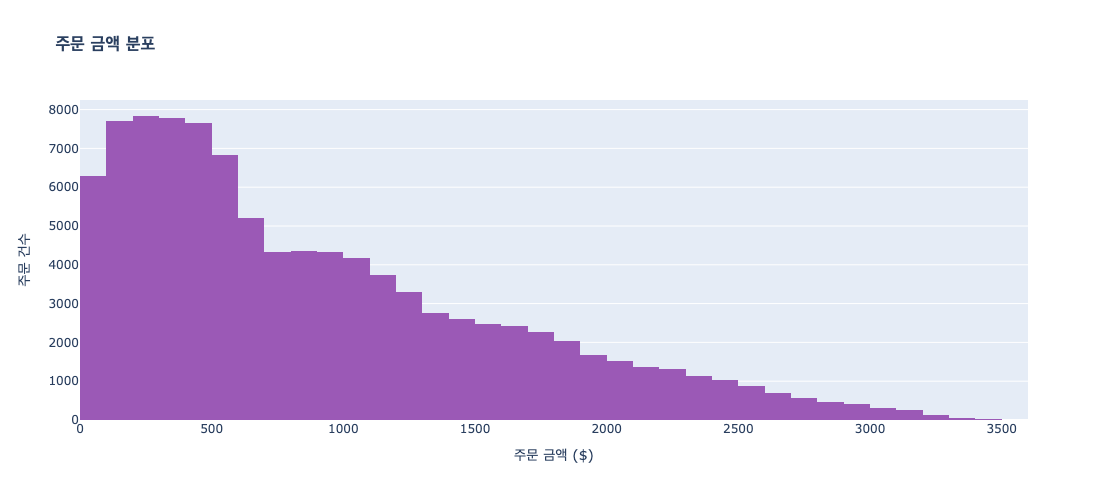

In [20]:
# 주문 금액 분포
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=df['TotalAmount'],
    nbinsx=50,
    marker_color='#9b59b6'
))

fig.update_layout(
    title='<b>주문 금액 분포</b>',
    xaxis_title='주문 금액 ($)',
    yaxis_title='주문 건수',
    height=500
)

fig.show()

In [21]:
# 카테고리별 평균 주문 금액
category_amount = df.groupby('Category')['TotalAmount'].agg(['mean', 'median', 'count']).reset_index()
category_amount.columns = ['카테고리', '평균', '중앙값', '주문건수']
category_amount = category_amount.sort_values('평균', ascending=False)

category_amount

,카테고리,평균,중앙값,주문건수
1,Clothing,927.878673,726.730,16439
2,Electronics,924.714720,718.280,16853
5,Toys & Games,919.881815,721.665,16542
4,Sports & Outdoors,913.209467,709.005,16804
3,Home & Kitchen,912.940359,707.735,16610
0,Books,911.045667,704.800,16752


In [22]:
# 고객별 주문 통계
customer_orders = df.groupby('CustomerID').agg({
    'OrderDate': 'count',
    'TotalAmount': 'sum'
}).reset_index()
customer_orders.columns = ['CustomerID', '주문횟수', '총구매금액']

print(f"총 고객 수: {df['CustomerID'].nunique():,}명")
print(f"\n주문 횟수:")
print(f"  평균: {customer_orders['주문횟수'].mean():.2f}회")
print(f"  중앙값: {customer_orders['주문횟수'].median():.0f}회")
print(f"  최대: {customer_orders['주문횟수'].max()}회")
print(f"\n총 구매 금액:")
print(f"  평균: ${customer_orders['총구매금액'].mean():.2f}")
print(f"  중앙값: ${customer_orders['총구매금액'].median():.2f}")
print(f"  최대: ${customer_orders['총구매금액'].max():.2f}")

총 고객 수: 43,233명

주문 횟수:
  평균: 2.31회
  중앙값: 2회
  최대: 10회

총 구매 금액:
  평균: $2123.97
  중앙값: $1805.41
  최대: $15215.79


In [23]:
# 주문 횟수 분포
order_freq = customer_orders['주문횟수'].value_counts().reset_index()
order_freq.columns = ['주문횟수', '고객수']
order_freq = order_freq.sort_values('주문횟수')

order_freq

,주문횟수,고객수
0,1,13532
1,2,13504
2,3,8994
3,4,4635
4,5,1736
5,6,628
6,7,159
7,8,30
8,9,13
9,10,2


In [24]:
# 재구매 고객 분석
repeat_customers = (customer_orders['주문횟수'] > 1).sum()
repeat_rate = repeat_customers / len(customer_orders) * 100

print(f"1회 구매 고객: {(customer_orders['주문횟수'] == 1).sum():,}명 ({((customer_orders['주문횟수'] == 1).sum() / len(customer_orders) * 100):.2f}%)")
print(f"재구매 고객: {repeat_customers:,}명 ({repeat_rate:.2f}%)")
print(f"\n재구매 고객 평균 주문 횟수: {customer_orders[customer_orders['주문횟수'] > 1]['주문횟수'].mean():.2f}회")

1회 구매 고객: 13,532명 (31.30%)
재구매 고객: 29,701명 (68.70%)

재구매 고객 평균 주문 횟수: 2.91회


## 10. EDA 요약

### 핵심 인사이트

1. **데이터 품질**: 결측치 및 중복 데이터 없이 양질의 데이터 확보
2. **고객 재구매 패턴**: 전체 고객 중 약 68.70%가 재구매 고객 (29,701명)
3. **카테고리 분포**: 6개 주요 카테고리가 비교적 균등하게 분포 (각 16~17%)
4. **할인 활용**: 전체 주문의 약 59% 이상이 할인 혜택 활용 (평균 할인율 12.36%)
5. **결제 다양성**: 4가지 결제 수단 중 Credit Card가 가장 많이 사용됨 (약 36%)

---

### 주요 통계

| 항목 | 값 |
|------|-----|
| **전체 주문 건수** | 100,000건 |
| **분석 기간** | 2020-01-01 ~ 2024-12-31 (1,826일) |
| **총 고객 수** | 43,233명 |
| **재구매 고객** | 29,701명 (68.70%) |
| **평균 주문 횟수** | 2.31회 |
| **평균 주문 금액** | $412.11 |
| **평균 할인율** | 12.36% (할인 받은 주문 기준) |